## On the use of hierarchical Bayesian modelling for stochastic crack growth monitoring

### Case 2 - Modelling crack growth in ship structures using a spectral fatigue analysis and a stochastic modified Paris' law model

This notebook demonstrates the principles of the proposed hierarchical Bayesian modelling framework using data obtained from a physics-based stochastic simulation that generates crack growth data for structural components in ship structures, operating under realistic conditions. The framework employed to generate these results is presented in Makris et al. (2023).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader

In [3]:
data_loader = SCGDataLoader()

In [4]:
data = data_loader.load_data()

In [5]:
%matplotlib inline

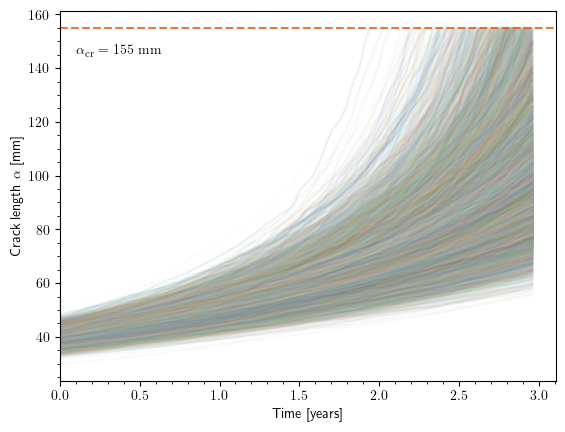

In [6]:
from src.visualisation import plot_scg_data

plot_scg_data(data["times"], data["crack_lengths"], save_fig_name="scg_data.pdf")

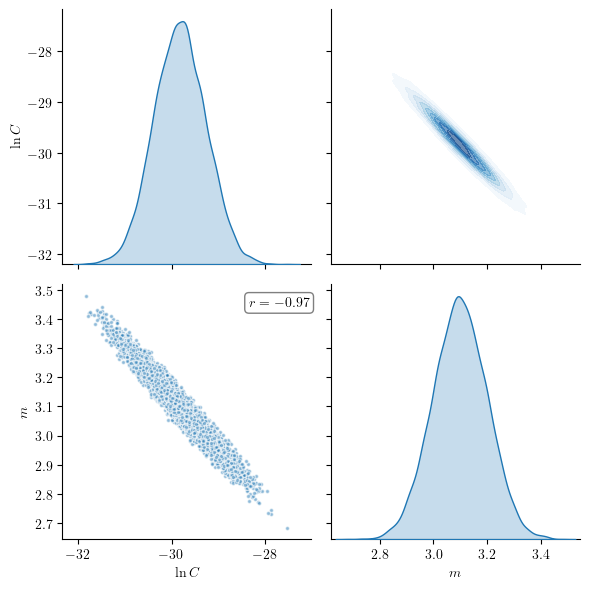

In [7]:
from src.visualisation import paris_params_pair_plot
paris_params_pair_plot(data["paris_c"], data["paris_m"], save_fig_name="paris_params_pair_plot.pdf")

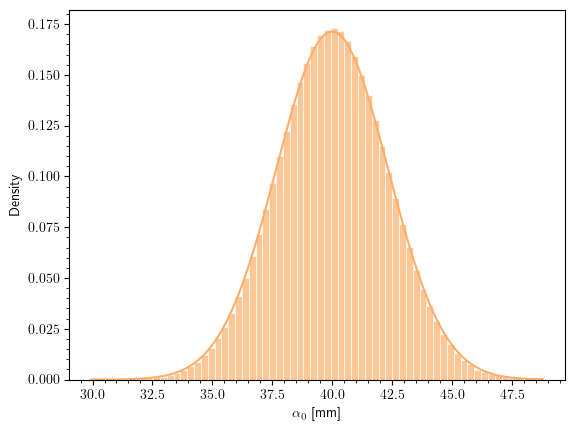

In [8]:
from src.visualisation import plot_initial_crack_length
plot_initial_crack_length(data["initial_crack_length"], save_fig_name="a0_hist.pdf")

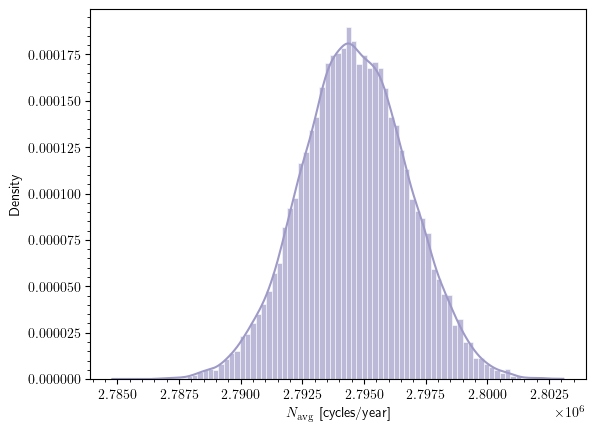

In [9]:
from src.visualisation import plot_avg_cycles
plot_avg_cycles(data["avg_cycles"], save_fig_name="avg_cycles_hist.pdf")

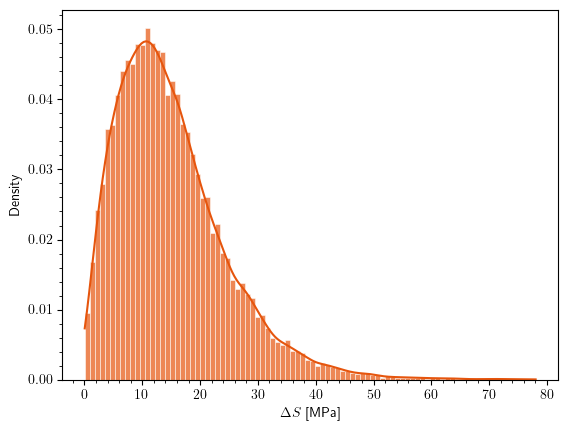

In [10]:
from src.visualisation import plot_stress_ranges
plot_stress_ranges(data["stress_ranges"], save_fig_name="stress_ranges_hist.pdf")

## Visualizing Selected Crack Growth Trajectories

Here we demonstrate the new functions for visualizing selected trajectories and observations.

In [11]:
# Import our new trajectory selector and observation generator
from src.data_utils import TrajectorySelector, CrackObservationGenerator
from src.visualisation import plot_selected_trajectories, plot_trajectories_with_observations

In [12]:
# First, let's select some trajectories with similar Paris law parameters
trajectory_selector = TrajectorySelector(data)

# Set target parameters for selection (similar to what we did in the HBM_for_SCG notebook)
# This will internally calculate target parameters based on the data statistics
trajectory_selector._set_target_parameters(scale_logc=-1.5, scale_m=1.5)

# Select trajectories that are within 1% of the standard deviation from the targets
selected_indices = trajectory_selector.select_by_radius(radius=0.01)
print(f"Found {len(selected_indices)} trajectories matching the criteria")

# Extract the selected trajectories
selected_trajectories = trajectory_selector.extract_trajectories(selected_indices)

# Print Paris parameters of selected trajectories
print("Paris parameters of selected trajectories:")
for i, (c, m) in enumerate(zip(selected_trajectories['paris_c'], selected_trajectories['paris_m'])):
    print(f"Trajectory {i+1}: C={c:.2e}, m={m:.4f}")

Found 3 trajectories matching the criteria
Paris parameters of selected trajectories:
Trajectory 1: C=4.80e-14, m=3.2491
Trajectory 2: C=4.82e-14, m=3.2482
Trajectory 3: C=4.79e-14, m=3.2494


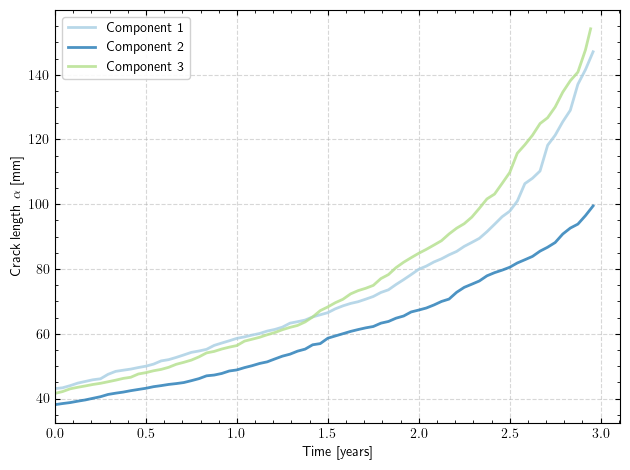

In [13]:
# Visualize the selected trajectories
fig, ax = plot_selected_trajectories(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    alpha=0.8,
    save_fig_name="selected_trajectories_pm.pdf"
)

## Simulating and Visualizing Crack Observations

Now let's generate simulated observations from these trajectories and visualize them.

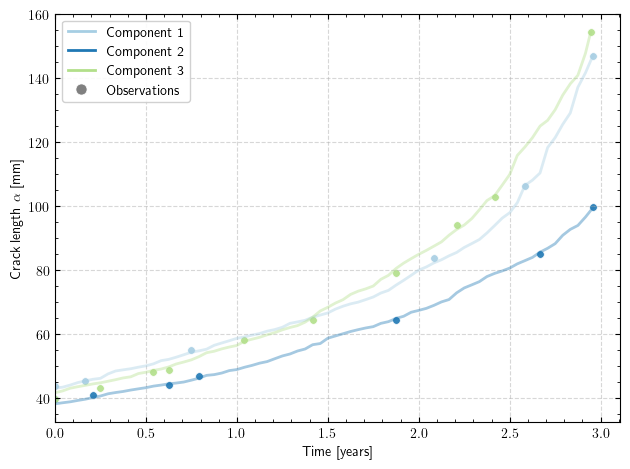

In [14]:
# Create an observation generator based on the selected trajectories
obs_generator = CrackObservationGenerator(selected_trajectories, random_seed=42)

# Generate observations using random sampling with noise
observations = obs_generator.create_observations(
    n_points=[6, 7, 10],           # 10 observations per trajectory
    strategy='random',     # Random sampling across the timeline
    std_dev=1.0,           # 1mm standard deviation measurement noise
    include_endpoints=True,  # Always include start and end points
    random_seed=42
)

# Visualize the trajectories with observations
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=observations['times'],
    obs_lengths=observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,        # Make the trajectories slightly transparent
    obs_alpha=0.9,         # Make the observations more visible
    marker_size=30,        # Increase marker size for visibility
    save_fig_name="trajectories_with_observations.pdf"
)

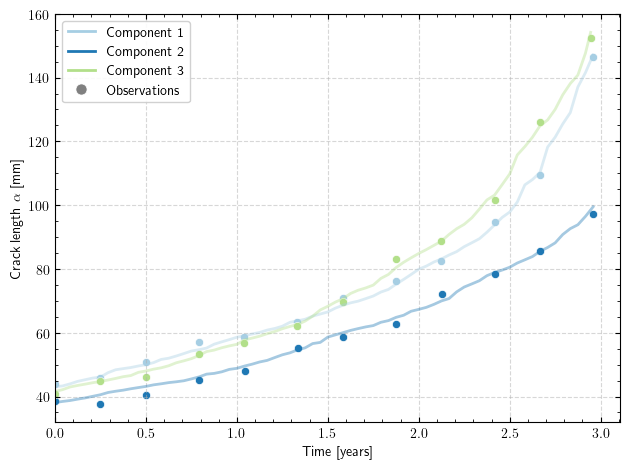

In [15]:
# Let's also try uniform sampling, which is more systematic
uniform_observations = obs_generator.create_observations(
    n_points=12,            # 8 observations per trajectory
    strategy='uniform',    # Evenly spaced observations
    std_dev=1.5,           # Slightly higher noise for demonstration
    include_endpoints=True,
    random_seed=42
)

# Visualize with uniform sampling
fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=uniform_observations['times'],
    obs_lengths=uniform_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.4,
    obs_alpha=1.0,
    marker_size=35,
    save_fig_name="uniform_observations.pdf"
)

# Add title to indicate this is uniform sampling
# ax.set_title("Crack Growth Trajectories with Uniformly Sampled Observations")

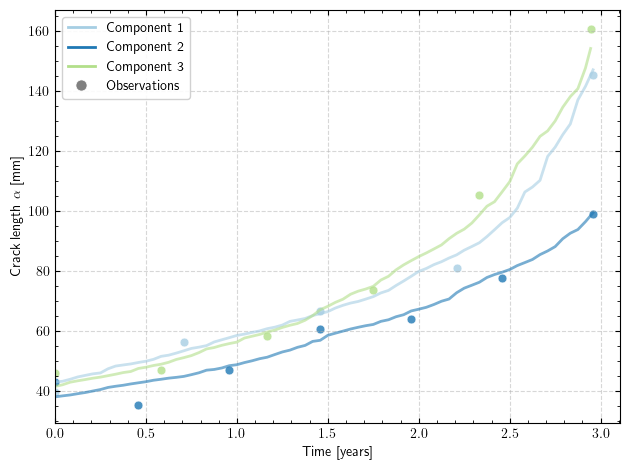

In [16]:
# Finally, let's demonstrate different noise levels
# Higher noise to illustrate measurement uncertainty
high_noise_observations = obs_generator.create_observations(
    n_points=[5, 7, 6],    # Different number of points for each trajectory
    strategy='uniform',
    std_dev=3.0,           # Higher noise level
    include_endpoints=True,
    random_seed=123
)

fig, ax = plot_trajectories_with_observations(
    times=selected_trajectories['times'],
    crack_lengths=selected_trajectories['crack_lengths'],
    obs_times=high_noise_observations['times'],
    obs_lengths=high_noise_observations['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(len(selected_indices))],
    cmap_name='Paired',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=0.8,
    marker_size=40,
    save_fig_name="high_noise_observations.pdf"
)

# Add title to indicate the high noise level
# ax.set_title(r"Crack Growth Trajectories with High Measurement Uncertainty ($\sigma = 3.0$ mm)")

# Add text to explain what's being shown
# ax.text(0.02, 0.02, 
#         "Solid lines: True crack growth trajectories\nPoints: Simulated measurements with noise", 
#         transform=ax.transAxes, 
#         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'),
#         fontsize=9)

## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [17]:
import numpy as np

In [18]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace

# Set a seed for reproducibility
np.random.seed(42)

In [19]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.HalfNormal(2.0),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

In [38]:
# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(selected_trajectories['paris_c'][component_idx])
true_m = selected_trajectories['paris_m'][component_idx]
true_a0 = selected_trajectories['initial_crack_length'][component_idx]

print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")

True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


In [39]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/src/bayesian_models.py:152: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 4000/4000 [00:03<00:00, 1258.99it/s, 1023 steps of size 1.82e-03. acc. prob=0.92]


In [40]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                                mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds                            10.261  4.589    3.257   19.000      0.151   
logc                         -30.606  1.651  -33.658  -27.500      0.056   
m                              3.839  0.145    3.563    4.103      0.004   
noise_std                      2.122  0.471    1.377    3.024      0.014   
predicted_crack_lengths[0]    43.952  0.100   43.773   44.140      0.003   
predicted_crack_lengths[1]    47.614  0.211   47.234   48.013      0.006   
predicted_crack_lengths[2]    51.883  0.333   51.285   52.519      0.009   
predicted_crack_lengths[3]    56.915  0.466   56.094   57.822      0.013   
predicted_crack_lengths[4]    62.926  0.606   61.821   64.080      0.016   
predicted_crack_lengths[5]    70.211  0.746   68.790   71.572      0.020   
predicted_crack_lengths[6]    79.201  0.872   77.567   80.816      0.022   
predicted_crack_lengths[7]    90.529  0.959   88.734   92.314      0.023   
predicted_cr

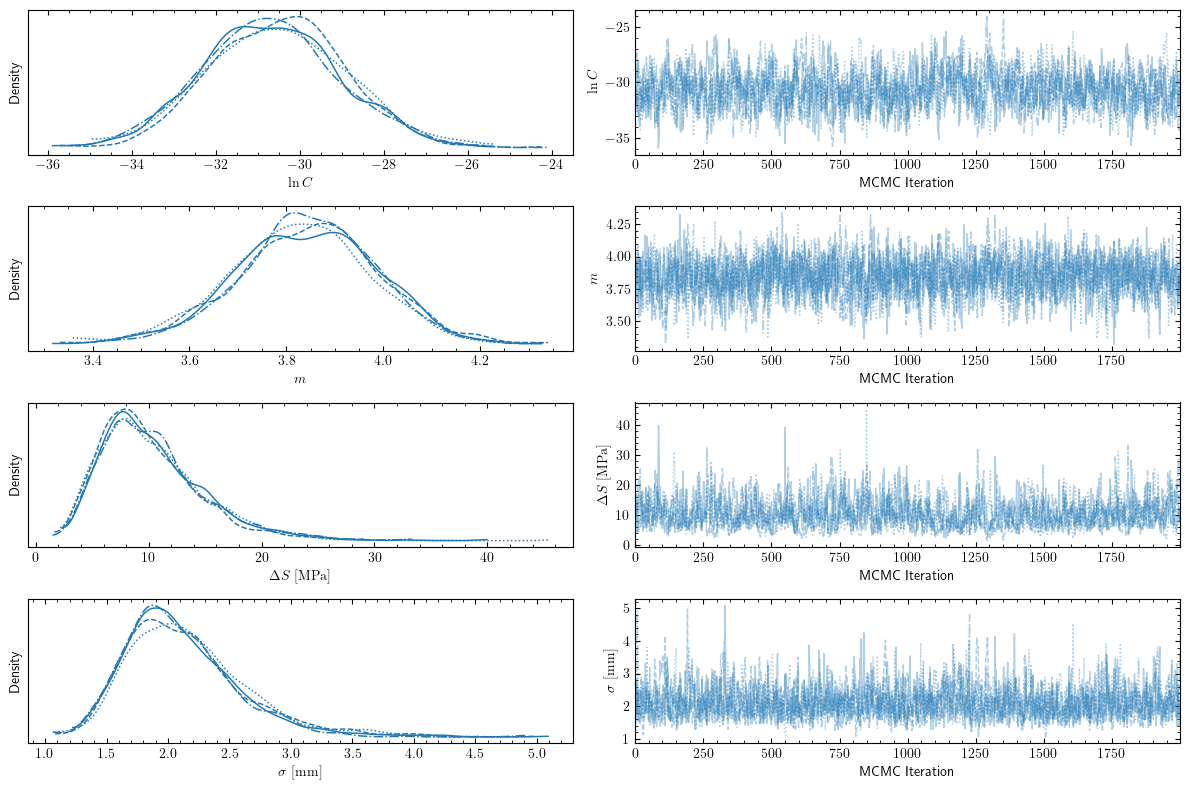

In [41]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="posterior_traces_stl_c3.pdf", compact=True)

## Comparing Prior and Posterior Distributions

We can use the new `plot_prior_posterior_comparison` function to visualize both prior and posterior distributions alongside the true parameter values and the posterior mode.

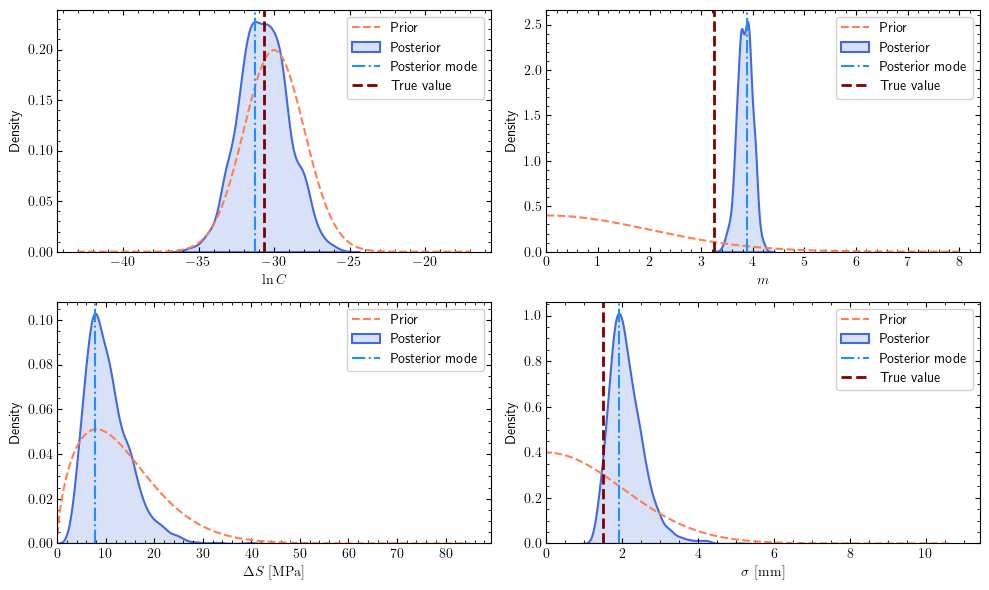

In [42]:
# Import necessary modules
import numpy as np
import numpyro.distributions as dist
from src.visualisation import plot_prior_posterior_comparison

# # Define the priors (same as used in the model)
# priors = {
#     "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
#     "m": dist.Normal(3.2, 0.5),           # Paris law exponent
#     "ds": dist.Gamma(5.0, 0.3),           # Stress range (MPa)
#     "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
# }

# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "noise_std": 1.5  # Noise used in generating observations
}

# Extract posterior samples
posterior_samples = results['samples']

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(10.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_posterior_comparison_stl_c3.pdf",
    use_first_chain_only=True,
    prior_range_extension=2.5
)

In [43]:
# Generate predictions using the preferred posterior predictive sampling method
# Note: The legacy generate_predictions method is deprecated
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [44]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = selected_trajectories['times'][component_idx]
true_crack_lengths = selected_trajectories['crack_lengths'][component_idx]
observed_times = uniform_observations['times'][component_idx]
observed_crack_lengths = uniform_observations['noisy_crack_lengths'][component_idx]


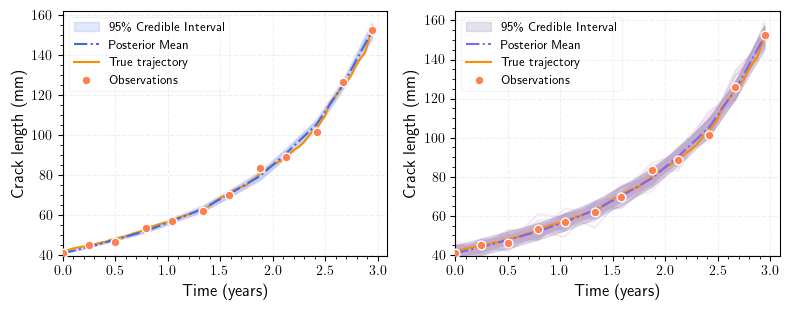

In [45]:
# Plot posterior predictive samples with true values and observations
fig1, ax1, stats1 = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=100,
    figsize=(8, 3.2),
    save_fig_name="posterior_predictive_predictions_stl_c3.pdf"
)

## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [46]:
# Ignore warnings about available devices for numpyro
import warnings
warnings.filterwarnings("ignore")

In [47]:
# Now let's run the model on all three components to compare performance
component_results = []

for i in range(len(selected_indices)):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(selected_trajectories['paris_c'][i])
    true_m = selected_trajectories['paris_m'][i]
    true_a0 = selected_trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=uniform_observations)
    results = model.run_inference(
        component_idx=i,
        num_warmup=2000,
        num_samples=2000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['samples']['logc'],
            'm': results['samples']['m'],
            'ds': results['samples']['ds'],
            'noise_std': results['samples']['noise_std'],
        }
    })


Running inference for component 1...
True parameters for component 1:
logC: -30.6669
m: 3.2491
a0: 43.0770


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1474.68it/s, 1023 steps of size 2.25e-03. acc. prob=0.92]



Running inference for component 2...
True parameters for component 2:
logC: -30.6630
m: 3.2482
a0: 38.1200


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1636.22it/s, 1023 steps of size 3.74e-03. acc. prob=0.91]



Running inference for component 3...
True parameters for component 3:
logC: -30.6687
m: 3.2494
a0: 41.5960


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1396.33it/s, 1023 steps of size 1.67e-03. acc. prob=0.95]


In [49]:
from src.output_utils import create_comparison_summary, save_comparison_summary

In [50]:
comparison_df = create_comparison_summary(component_results)
display(comparison_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
logc_target,-30.66693,-30.663003,-30.66868
logc_mean,-31.059851,-30.209299,-30.592777
logc_std,1.919049,1.705854,1.697826
logc_hdi_lower,-34.671421,-33.430099,-33.797226
logc_hdi_upper,-27.257322,-26.79813,-27.249592
logc_rmse,1.958862,1.765159,1.699522
logc_mape,5.121038,4.590424,4.431211
m_target,3.2491,3.2482,3.2494
m_mean,4.765043,3.63232,3.845001


In [51]:
save_comparison_summary(comparison_df, "stl_spectral_comparison_summary", "csv")

'/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/stl_spectral_comparison_summary.csv'

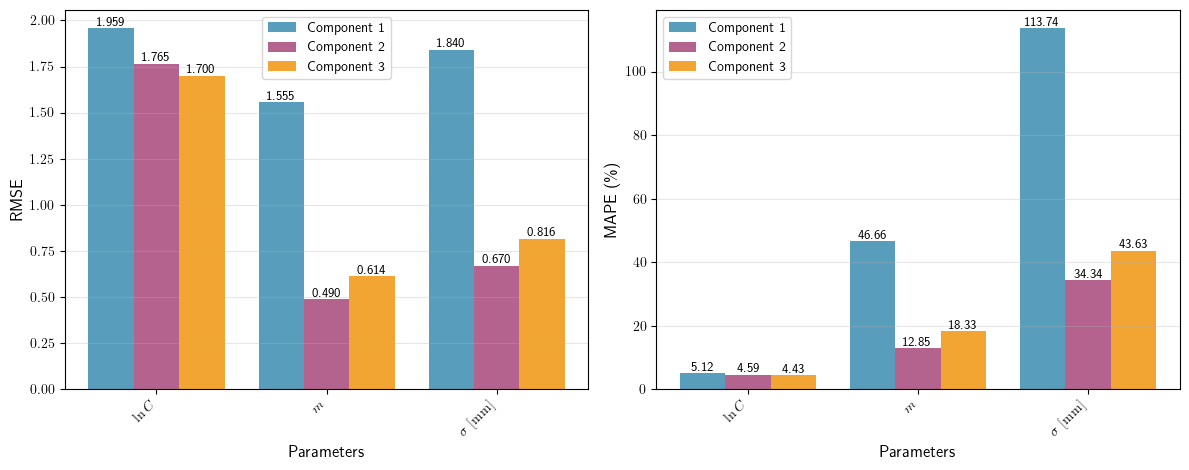

In [52]:
from src.visualisation import plot_performance_metrics
# Plot performance metrics for the comparison
fig, ax = plot_performance_metrics(summary_df=comparison_df,
                                   parameter_labels=plot_labels,
                                   figsize=(12., 4.8),
                                   colors=['#2E86AB', '#A23B72', '#F18F01'],
                                   save_fig_name="stl_performance_comparison_spectral.pdf")

### Multi-task Learning

Let's try to learn all tasks simultaneously! We will employ a hierarchical Bayesian model where we assign common priors.